In [30]:
from sklearn.datasets import make_classification

Learning Working of Perceptron:-

In [31]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False,class_sep=10)

In [32]:
import seaborn as sns
import pandas as pd

<Axes: xlabel='0', ylabel='1'>

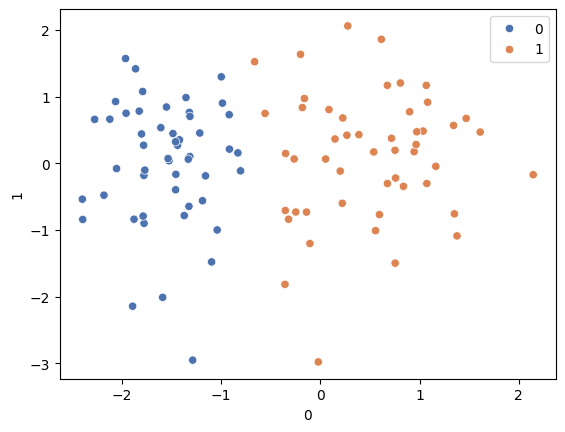

In [33]:
df = pd.DataFrame(X)

# Scatter plot using first two features

sns.scatterplot(

    x=df[0],

    y=df[1],

    hue=y,

    palette="deep"

)


In [114]:
df.iloc[31]
    

0    1.349900
1   -0.758693
Name: 31, dtype: float64

In [96]:
z = df.sample(1)
idx = z.index[0]

In [99]:
z

,0,1
81,1.341869,0.568684


In [76]:
y[int(z.index[0])]

np.int64(1)

In [110]:
y[31]

np.int64(1)

In [88]:
import numpy as np

def perceptron(df, y):
    
    w0 = 0
    w1 = 1
    w2 = 1
    
    epoch = 1000
    lr = 0.01

    for i in range(epoch):

        # random sample
        z = df.sample(1)

        # row index
        idx = z.index[0]

        # feature values
        x1 = z.iloc[0, 0]
        x2 = z.iloc[0, 1]

        # actual label
        y_true = y[idx]

        # linear equation
        y_pred = w0 + w1 * x1 + w2 * x2

        # step activation
        if y_pred >= 0:
            y_hat = 1
        else:
            y_hat = 0

        # perceptron update
        w0 = w0 + lr * (y_true - y_hat)
        w1 = w1 + lr * (y_true - y_hat) * x1
        w2 = w2 + lr * (y_true - y_hat) * x2

    return w0, w1, w2

In [100]:
w0, w1, w2 = perceptron(df,y)

In [102]:
def prediction(x1,x2,w0 = w0, w1 = w1, w2 = w2):
    y_pred = w0 + x1 * w1 + x2 * w2
    if y_pred >= 0:
        return 1
    else:
        return 0
    


In [115]:
prediction(1.349900,-0.758693)

1

In [116]:
y[31]

np.int64(1)

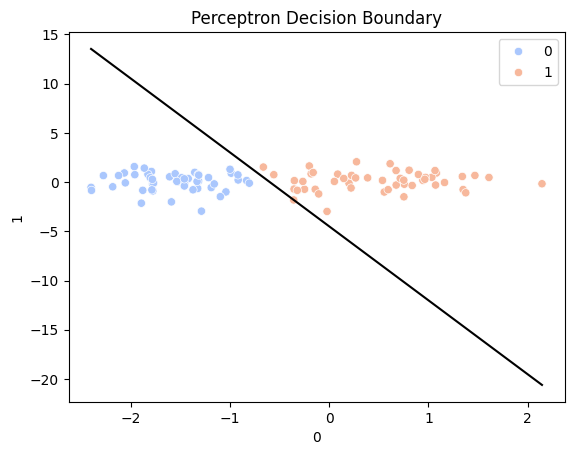

In [117]:
import matplotlib.pyplot as plt

# scatter plot of data

sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,1], hue=y, palette="coolwarm")

# create x range for line

x_vals = np.linspace(df.iloc[:,0].min(), df.iloc[:,0].max(), 100)

# decision boundary line

y_vals = -(w0 + w1 * x_vals) / w2

# plot line

plt.plot(x_vals, y_vals, color="black")

plt.title("Perceptron Decision Boundary")

plt.show()

Learning about Loss function and Gradient descent:-

In [2]:
import numpy as np

# sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# cross-entropy loss
def compute_loss(y, y_hat):
    # add epsilon to avoid log(0)
    eps = 1e-15
    y_hat = np.clip(y_hat, eps, 1 - eps)
    
    return -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))


# training data (OR gate example)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 1])

# initialize weights and bias
w = np.random.randn(2)
b = 0.0

lr = 0.1
epochs = 1000
loss_history = []
for epoch in range(epochs):
    total_loss = 0
    
    for i in range(len(X)):
        x_i = X[i]
        y_i = y[i]

        # forward pass
        z = np.dot(w, x_i) + b
        y_hat = sigmoid(z)

        # loss
        loss = compute_loss(y_i, y_hat)
        total_loss += loss

        # gradient descent
        dz = y_hat - y_i          # derivative of cross-entropy + sigmoid
        dw = dz * x_i
        db = dz

        w -= lr * dw
        b -= lr * db
        loss_history.append(total_loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss:.4f}")


# final predictions
print("\nFinal predictions:")
for x_i in X:
    pred = sigmoid(np.dot(w, x_i) + b)
    print(x_i, "->", pred)

Epoch 0, Loss: 2.0855
Epoch 100, Loss: 0.6710
Epoch 200, Loss: 0.4078
Epoch 300, Loss: 0.2903
Epoch 400, Loss: 0.2241
Epoch 500, Loss: 0.1819
Epoch 600, Loss: 0.1529
Epoch 700, Loss: 0.1316
Epoch 800, Loss: 0.1155
Epoch 900, Loss: 0.1028

Final predictions:
[0 0] -> 0.05058546374661539
[0 1] -> 0.9801088049226735
[1 0] -> 0.9797768777495174
[1 1] -> 0.99997768135764


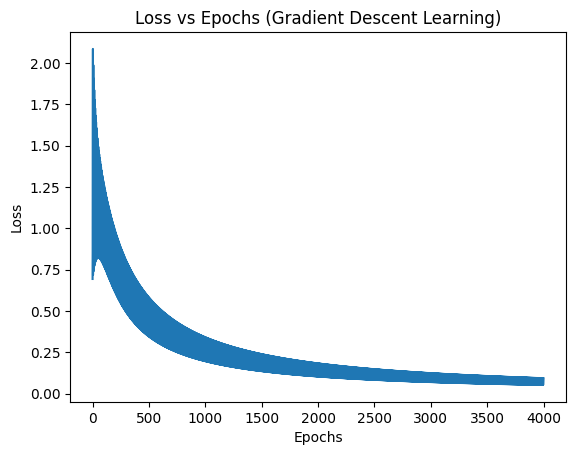

In [3]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.title("Loss vs Epochs (Gradient Descent Learning)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

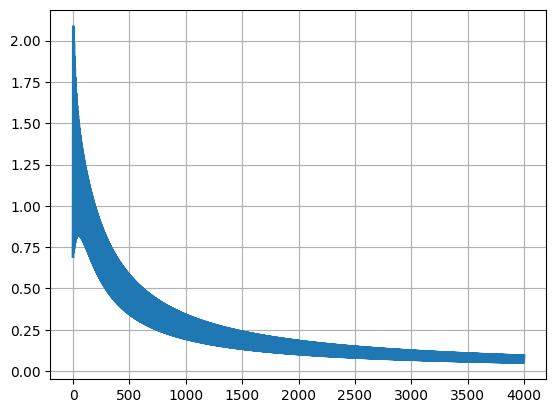

In [4]:
plt.plot(loss_history, linewidth=2)
plt.grid(True)